In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

In [81]:
import numpy as np
import pandas as pd
import seaborn as sns # iris(데이터프레임)가져오기
from sklearn import datasets # iris(X와 y가 분리되서 numpy) 가져오기
from sklearn.preprocessing import LabelEncoder # 라벨 인코더
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt

'''
- 데이터셋 생성 및 전처리
  x,y (라벨인코딩)분리-> train_test_split 분리(8:2)
- 모델 구성(입력4, 출력3, layer : 4->64->128->50->30->3)
- 학습과정 설정(loss='sparse_categorical_crossentropy')
- 학습
- 모델평가(가장 최선의 모델을 get)
- 모델사용(저장/예측)
'''
# 1. 기본적인 DNN
## 1. 데이터셋 생성 및 전처리

In [82]:
iris = sns.load_dataset('iris')
iris['species'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [83]:
iris_X=iris.iloc[:,:-1].values
labelEncoder = LabelEncoder()
iris_y = labelEncoder.fit_transform(iris.iloc[:,-1])
iris_X.shape,iris_y.shape


((150, 4), (150,))

In [84]:
# iris가져오기 방법2
iris = datasets.load_iris()
iris_X = iris.data
iris_y = iris.target
print(iris.target_names)
iris_X.shape, iris_y.shape

['setosa' 'versicolor' 'virginica']


((150, 4), (150,))

In [85]:
# 학습셋과 테스트셋 분리
train_X, test_X,train_y, test_y = train_test_split(iris_X,iris_y,
                                                  test_size=0.2,
                                                  stratify=iris_y 
                                                  )
np.c_[pd.Series(iris_y).value_counts(normalize=True)]
np.c_[pd.Series(train_y).value_counts(normalize=True)]
np.c_[pd.Series(test_y).value_counts(normalize=True)]

array([[0.33333333],
       [0.33333333],
       [0.33333333]])

In [86]:
train_X.shape,train_y.shape, test_X.shape, test_y.shape

((120, 4), (120,), (30, 4), (30,))

## 2. 모델학습구성
- 4->64->128->50->30->3


In [87]:
model = Sequential([
    Input(4),
    Dense(units=64, activation='relu'),
    Dense(units=128, activation='relu'),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax')
],'sequential')
# model = Sequential(name='sequential')
# model.add(Input(4))
# model.add(Dense(units=64,activation='relu'))
# model.add(Dense(units=128,activation='relu'))
# model.add(Dense(units=50,activation='relu'))
# model.add(Dense(units=30,activation='relu'))
# model.add(Dense(units=3,activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_25 (Dense)            (None, 64)                320       
                                                                 
 dense_26 (Dense)            (None, 128)               8320      
                                                                 
 dense_27 (Dense)            (None, 50)                6450      
                                                                 
 dense_28 (Dense)            (None, 30)                1530      
                                                                 
 dense_29 (Dense)            (None, 3)                 93        
                                                                 
Total params: 16,713
Trainable params: 16,713
Non-trainable params: 0
_________________________________________________________________


In [88]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
earlystopping = EarlyStopping(patience=50)
model_save_folder = 'model/'
import os
if not os.path.exists(model_save_folder):
    os.mkdir(model_save_folder)

file = model_save_folder + 'iris-{epoch:03d}-loss{val_loss:.4f}-acc{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(monitor='val_loss',
                            filepath=file,# 모델 저장 파일
                            save_best_only=True,  # 모니터 지표가 개선된 경우만 모델 저장                         
                            verbose=1)  # 저장 여부 로그 출력
hist = model.fit(train_X,train_y,
                epochs=200,
                validation_split=0.1,
                callbacks=[earlystopping,checkpoint],
                verbose=2)

Epoch 1/200

Epoch 1: val_loss improved from inf to 0.92657, saving model to model\iris-001-loss0.9266-acc0.4167.h5
4/4 - 1s - loss: 0.9710 - accuracy: 0.6852 - val_loss: 0.9266 - val_accuracy: 0.4167 - 854ms/epoch - 213ms/step
Epoch 2/200

Epoch 2: val_loss improved from 0.92657 to 0.86080, saving model to model\iris-002-loss0.8608-acc0.5000.h5
4/4 - 0s - loss: 0.8418 - accuracy: 0.7037 - val_loss: 0.8608 - val_accuracy: 0.5000 - 124ms/epoch - 31ms/step
Epoch 3/200

Epoch 3: val_loss improved from 0.86080 to 0.77837, saving model to model\iris-003-loss0.7784-acc0.5000.h5
4/4 - 0s - loss: 0.7479 - accuracy: 0.7037 - val_loss: 0.7784 - val_accuracy: 0.5000 - 96ms/epoch - 24ms/step
Epoch 4/200

Epoch 4: val_loss improved from 0.77837 to 0.68817, saving model to model\iris-004-loss0.6882-acc0.5833.h5
4/4 - 0s - loss: 0.6613 - accuracy: 0.8148 - val_loss: 0.6882 - val_accuracy: 0.5833 - 102ms/epoch - 25ms/step
Epoch 5/200

Epoch 5: val_loss improved from 0.68817 to 0.61243, saving model to

Epoch 42/200

Epoch 42: val_loss did not improve from 0.02398
4/4 - 0s - loss: 0.0461 - accuracy: 0.9815 - val_loss: 0.0738 - val_accuracy: 1.0000 - 73ms/epoch - 18ms/step
Epoch 43/200

Epoch 43: val_loss did not improve from 0.02398
4/4 - 0s - loss: 0.0499 - accuracy: 0.9815 - val_loss: 0.0270 - val_accuracy: 1.0000 - 78ms/epoch - 19ms/step
Epoch 44/200

Epoch 44: val_loss improved from 0.02398 to 0.02365, saving model to model\iris-044-loss0.0237-acc1.0000.h5
4/4 - 0s - loss: 0.0421 - accuracy: 0.9907 - val_loss: 0.0237 - val_accuracy: 1.0000 - 102ms/epoch - 25ms/step
Epoch 45/200

Epoch 45: val_loss did not improve from 0.02365
4/4 - 0s - loss: 0.0423 - accuracy: 0.9907 - val_loss: 0.0244 - val_accuracy: 1.0000 - 50ms/epoch - 12ms/step
Epoch 46/200

Epoch 46: val_loss did not improve from 0.02365
4/4 - 0s - loss: 0.0392 - accuracy: 0.9907 - val_loss: 0.0390 - val_accuracy: 1.0000 - 56ms/epoch - 14ms/step
Epoch 47/200

Epoch 47: val_loss did not improve from 0.02365
4/4 - 0s - loss: 

Epoch 86/200

Epoch 86: val_loss improved from 0.00367 to 0.00352, saving model to model\iris-086-loss0.0035-acc1.0000.h5
4/4 - 0s - loss: 0.0327 - accuracy: 0.9722 - val_loss: 0.0035 - val_accuracy: 1.0000 - 93ms/epoch - 23ms/step
Epoch 87/200

Epoch 87: val_loss did not improve from 0.00352
4/4 - 0s - loss: 0.0409 - accuracy: 0.9815 - val_loss: 0.0058 - val_accuracy: 1.0000 - 56ms/epoch - 14ms/step
Epoch 88/200

Epoch 88: val_loss did not improve from 0.00352
4/4 - 0s - loss: 0.0169 - accuracy: 1.0000 - val_loss: 0.0183 - val_accuracy: 1.0000 - 60ms/epoch - 15ms/step
Epoch 89/200

Epoch 89: val_loss did not improve from 0.00352
4/4 - 0s - loss: 0.0253 - accuracy: 0.9907 - val_loss: 0.0078 - val_accuracy: 1.0000 - 55ms/epoch - 14ms/step
Epoch 90/200

Epoch 90: val_loss did not improve from 0.00352
4/4 - 0s - loss: 0.0270 - accuracy: 0.9907 - val_loss: 0.0062 - val_accuracy: 1.0000 - 54ms/epoch - 14ms/step
Epoch 91/200

Epoch 91: val_loss did not improve from 0.00352
4/4 - 0s - loss: 0

Epoch 132/200

Epoch 132: val_loss did not improve from 0.00247
4/4 - 0s - loss: 0.0150 - accuracy: 1.0000 - val_loss: 0.0083 - val_accuracy: 1.0000 - 59ms/epoch - 15ms/step
Epoch 133/200

Epoch 133: val_loss did not improve from 0.00247
4/4 - 0s - loss: 0.0229 - accuracy: 0.9815 - val_loss: 0.0045 - val_accuracy: 1.0000 - 52ms/epoch - 13ms/step
Epoch 134/200

Epoch 134: val_loss did not improve from 0.00247
4/4 - 0s - loss: 0.0292 - accuracy: 0.9907 - val_loss: 0.0027 - val_accuracy: 1.0000 - 50ms/epoch - 13ms/step
Epoch 135/200

Epoch 135: val_loss did not improve from 0.00247
4/4 - 0s - loss: 0.0436 - accuracy: 0.9907 - val_loss: 0.0083 - val_accuracy: 1.0000 - 54ms/epoch - 14ms/step
Epoch 136/200

Epoch 136: val_loss did not improve from 0.00247
4/4 - 0s - loss: 0.0230 - accuracy: 0.9815 - val_loss: 0.0225 - val_accuracy: 1.0000 - 49ms/epoch - 12ms/step
Epoch 137/200

Epoch 137: val_loss did not improve from 0.00247
4/4 - 0s - loss: 0.0236 - accuracy: 0.9815 - val_loss: 0.0032 - va

Epoch 178/200

Epoch 178: val_loss improved from 0.00102 to 0.00093, saving model to model\iris-178-loss0.0009-acc1.0000.h5
4/4 - 0s - loss: 0.0080 - accuracy: 1.0000 - val_loss: 9.3235e-04 - val_accuracy: 1.0000 - 96ms/epoch - 24ms/step
Epoch 179/200

Epoch 179: val_loss did not improve from 0.00093
4/4 - 0s - loss: 0.0180 - accuracy: 0.9907 - val_loss: 0.0016 - val_accuracy: 1.0000 - 58ms/epoch - 15ms/step
Epoch 180/200

Epoch 180: val_loss did not improve from 0.00093
4/4 - 0s - loss: 0.0086 - accuracy: 1.0000 - val_loss: 0.0056 - val_accuracy: 1.0000 - 77ms/epoch - 19ms/step
Epoch 181/200

Epoch 181: val_loss did not improve from 0.00093
4/4 - 0s - loss: 0.0173 - accuracy: 0.9907 - val_loss: 0.0019 - val_accuracy: 1.0000 - 57ms/epoch - 14ms/step
Epoch 182/200

Epoch 182: val_loss did not improve from 0.00093
4/4 - 0s - loss: 0.0475 - accuracy: 0.9907 - val_loss: 0.0013 - val_accuracy: 1.0000 - 49ms/epoch - 12ms/step
Epoch 183/200

Epoch 183: val_loss did not improve from 0.00093
4/

## 3. 모델평가



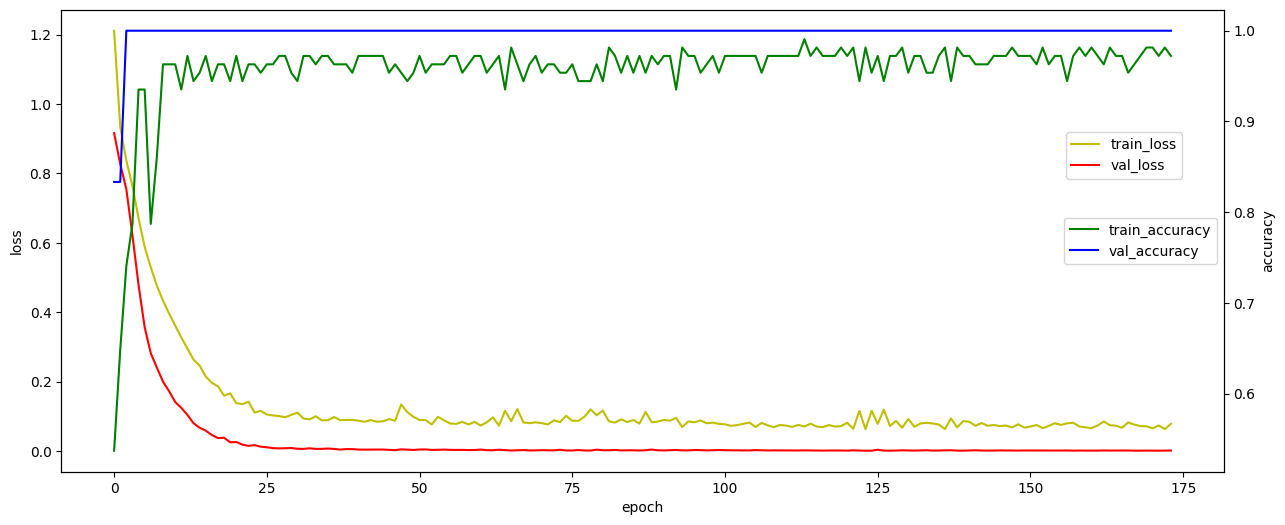

In [69]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')

#acc_ax.plot(hist.history['val_recall'],'k',label='val_recall')


acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [111]:
# 모델 평가
loss, acc = model.evaluate(test_X, test_y)
print(loss, acc)

1/1 [==============================] - 0s 34ms/step - loss: 0.2917 - accuracy: 0.9000
0.2916727364063263 0.8999999761581421


In [123]:
# 저장된 모델중 최선 모델
model1 = load_model('model/iris-044-loss0.0237-acc1.0000.h5')
loss1, acc1 = model1.evaluate(test_X, test_y)
print(loss1, acc1)

1/1 [==============================] - 0s 174ms/step - loss: 0.1671 - accuracy: 0.9333
0.16711653769016266 0.9333333373069763


 # 2. sklearn이용

In [113]:
from sklearn.neural_network import MLPClassifier
# 1.데이터
train_X.shape, train_y.shape,test_X.shape, test_y.shape

((120, 4), (120,), (30, 4), (30,))

In [114]:
# 2. 모델 생성
model = MLPClassifier(hidden_layer_sizes=(64, 128, 50, 30),
                     activation='relu',
                     solver='adam', # 옵티마이저
                     batch_size=40, # 학습시 batch_size
                     early_stopping=True, # 조기 종료 활성화,
                     n_iter_no_change=50, # earlystopping의 patience역할
                     validation_fraction=0.1, # 검증셋 비율
                     max_iter=200, 
                     warm_start=False, # True일 경우 이전학습에 이어서 학습
                     )

In [115]:
# 3. 모델 학습
model.fit(train_X, train_y)

MLPClassifier(batch_size=40, early_stopping=True,
              hidden_layer_sizes=(64, 128, 50, 30), n_iter_no_change=50)

In [116]:
# 4. 모델 평가
model.score(test_X, test_y)

0.9333333333333333

In [117]:
# 5. 교차표(혼동행렬)
# 실제값 : test_y
y_hat = model.predict(test_X)
pd.crosstab(test_y, y_hat, rownames=['real'], colnames=['predict'])

predict,0,1,2
real,,,
0,10,0,0
1,0,8,2
2,0,0,10


# 3. 클래스를 생성하여 모델 생성함수 사용


In [106]:
class DNNCLassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', output_dim=3,optimizer='adam'):
        #모델구성
        model = Sequential(layers=[
            Input(input_dim),
            Dense(units=50,activation=activation),
            Dense(units=30,activation=activation),
            Dense(units=output_dim,activation='softmax'),
            ],name='sequential')
        #모델학습설정
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer=optimizer,
                     metrics=['accuracy'])
        #모델 return
        return model

In [107]:
# 1. 데이터
print(train_X.shape, train_y.shape, test_X.shape,test_y.shape)
# 2. 모델
model=DNNCLassifier.build(input_dim=4, activation='relu', output_dim=3, optimizer='adam')
# 3. 모델학습
hist = model.fit(train_X, train_y,
                epochs=50,
                validation_split=0.1,
                verbose=0)

(120, 4) (120,) (30, 4) (30,)


In [108]:
# 모델 평가
loss, accuracy = model.evaluate(test_X, test_y, verbose=0)
print(f'정확도 : {accuracy*100}%')

정확도 : 89.99999761581421%


# 4. 함수형 API
- 병렬처리,Residual block

In [118]:
# 기존 model 스타일1
model = Sequential(layers=[
    Input(shape=(4,)),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax'),
])
# 기존 model 스타일2
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=3, activation='softmax'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            (None, 50)                250       
                                                                 
 dense_37 (Dense)            (None, 30)                1530      
                                                                 
 dense_38 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [119]:
# 함수형 API 스타일
from tensorflow.keras import Model
input_ = Input(shape=(4,))
layer1 = Dense(units=50, activation='relu')(input_)
layer2 = Dense(units=30, activation='relu')(layer1)
output = Dense(units=3, activation='softmax')(layer2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 4)]               0         
                                                                 
 dense_39 (Dense)            (None, 50)                250       
                                                                 
 dense_40 (Dense)            (None, 30)                1530      
                                                                 
 dense_41 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [120]:
# 4->160->3
# 기존의 model 방식
model = Sequential([
    Input(shape=(4,)),
    Dense(units=160, activation='relu'),
    Dense(units=3, activation='softmax')
])
# 함수형 API 방식
input_ = Input(shape=(4,))
layer  = Dense(units=160, activation='relu')(input_)
output = Dense(units=3,   activation='softmax')(layer)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 4)]               0         
                                                                 
 dense_44 (Dense)            (None, 160)               800       
                                                                 
 dense_45 (Dense)            (None, 3)                 483       
                                                                 
Total params: 1,283
Trainable params: 1,283
Non-trainable params: 0
_________________________________________________________________


In [125]:
# 4->160->3를 병렬처리 방식
from tensorflow.keras.layers import concatenate
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=80, activation='relu')(input_)
dense3 = Dense(units=30, activation='relu')(input_)
x      = concatenate([dense1, dense2, dense3])
output = Dense(units=3, activation='softmax')(x)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_15 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_54 (Dense)               (None, 50)           250         ['input_15[0][0]']               
                                                                                                  
 dense_55 (Dense)               (None, 80)           400         ['input_15[0][0]']               
                                                                                                  
 dense_56 (Dense)               (None, 30)           150         ['input_15[0][0]']               
                                                                                            

In [127]:
# 리지듀얼 블럭(Residual Block)
from tensorflow.keras.layers import add 
input_=Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
layer1 = Dense(units=64, activation='relu')(dense1)
layer2 = Dense(units=50, activation='relu')(layer1)
dense2 = add([dense1,layer2])
output = Dense(units=3, activation='softmax')(dense2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_17 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_62 (Dense)               (None, 50)           250         ['input_17[0][0]']               
                                                                                                  
 dense_63 (Dense)               (None, 64)           3264        ['dense_62[0][0]']               
                                                                                                  
 dense_64 (Dense)               (None, 50)           3250        ['dense_63[0][0]']               
                                                                                            